# Principal Component Analysis
<br>

### Import packages

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### My PCA code

In [2]:
class PCAAnalysis:
    def __init__(self, data):
        self.data = data
        self.mean_centered_data = None
        self.cov_matrix = None
        self.eigenvalues = None
        self.eigenvectors = None
        self.scores = None
        self.variance = None
        self.percent_variance = None

    def mean_centering(self):
        self.mean_centered_data = self.data - np.mean(self.data, axis=0)

    def compute_covariance_matrix(self):
        self.cov_matrix = np.cov(self.mean_centered_data, rowvar=False)

    def perform_eigen_decomposition(self):
        self.eigenvalues, self.eigenvectors = np.linalg.eig(self.cov_matrix)
        
        # prevent complex numbers
        self.eigenvalues = np.real(self.eigenvalues)
        self.eigenvectors = np.real(self.eigenvectors)
        
        # Sort eigenvalues and eigenvectors in descending order
        sorted_indices = np.argsort(self.eigenvalues)[::-1]
        self.eigenvalues = self.eigenvalues[sorted_indices]
        self.eigenvectors = self.eigenvectors[:, sorted_indices]

    def project_data(self):
        self.scores = np.dot(self.mean_centered_data, self.eigenvectors)

    def compute_variance(self):
        total_variance = np.sum(self.eigenvalues)
        self.variance = self.eigenvalues
        self.percent_variance = (self.eigenvalues / total_variance) * 100

    def perform_pca(self):
        self.mean_centering()
        self.compute_covariance_matrix()
        self.perform_eigen_decomposition()
        self.project_data()
        self.compute_variance()

    def results(self):
        return {
            "Variance": self.variance,
            "Percent Variance Explained": self.percent_variance,
            "Scores": self.scores,
            "Loadings": self.eigenvectors,
        }
    
    def diplay_result(self):
        print("Eigenvalues (Variance):")
        print(self.variance)

        print("\nPercent Variance Explained:")
        print(self.percent_variance)

        print("\nPrincipal Components (Eigenvectors):")
        print(self.eigenvectors)

        print("\nScores (Projected Data):")
        print(self.scores)
        
        
    def scree_plot(self, save_path=None):
        num_components = len(self.percent_variance)
        
        # Plot only the first 10 principal components if there are more than 10
        if num_components > 10:
            components_to_plot = self.percent_variance[:10]
            x_ticks = range(1, 11)
        else:
            components_to_plot = self.percent_variance
            x_ticks = range(1, num_components + 1)
        
        # Plotting the scree plot for percentage variance explained
        plt.figure(figsize=(8, 5))
        plt.plot(x_ticks, components_to_plot, 'o-', linewidth=2, color='blue')
        plt.title('Scree Plot - Percentage Variance Explained')
        plt.xlabel('Principal Component')
        plt.ylabel('Percentage Variance Explained')
        plt.ylim(0, 100)
        plt.xticks(x_ticks)
        plt.grid(True)
        if save_path:
            plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
        plt.show()
        
        
    def scores_plot(self, group_by_target=False, target_data=False, save_path=None):
        plt.figure(figsize=(8, 5))
        if group_by_target:
            pca_df = pd.DataFrame(data=self.scores[:,0:2], columns=['PC1', 'PC2'])
            pca_df['Target'] = target_data['sample_label']
            colors = {0: 'blue', 1: 'red'}
            for target_value, group in pca_df.groupby('Target'):
                plt.scatter(group['PC1'], group['PC2'], color=colors[target_value],
                            label=f'Target {target_value}')
        else:
            plt.scatter(self.scores[:, 0], self.scores[:, 1], alpha=0.7, edgecolor='k')
        plt.title('Scores Plot (PC1 vs PC2)')
        plt.xlabel('PC1 ({}%)'.format(round(self.percent_variance[0],2)))
        plt.ylabel('PC2 ({}%)'.format(round(self.percent_variance[1],2)))
        plt.legend()
        plt.grid(True)
        if save_path:
            plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
        plt.show()


    def loadings_plot(self, save_path=None):
        loadings = self.eigenvectors[:, :2]  # Loadings for PC1 and PC2
        plt.figure(figsize=(8, 5))
        plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
        plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)

        for i, (x, y) in enumerate(zip(loadings[:, 0], loadings[:, 1])):
            plt.arrow(0, 0, x, y, color='blue', alpha=0.8, head_width=0.05, length_includes_head=True)
            plt.text(x*1.15, y*1.04, self.data.columns[i], color='black', fontsize=10)

        plt.title('Loadings Plot (PC1 vs PC2)')
        plt.xlabel('PC1 Loadings')
        plt.ylabel('PC2 Loadings')
        plt.grid(color='gray', linestyle='--', linewidth=0.5)
        plt.axis('equal')
        if save_path:
            plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
        plt.show()

### Load the independent variables

In [3]:
df_x = pd.read_csv("C:/Users/nnamd/Documents/data/machine_learning/sandbox_3/sample_data_for_project_final.csv")
df_x

,Unnamed: 0,sample_1,sample_2,sample_3,sample_4,sample_5,sample_6,sample_7,sample_8,sample_9,...,sample_855,sample_856,sample_857,sample_858,sample_859,sample_860,sample_861,sample_862,sample_863,sample_864
0,variable_1,1.335571e+05,4.067772e+05,4.653638e+05,2.327503e+05,3.204984e+05,9.507953e+04,2.629849e+05,1.677002e+05,1.651118e+05,...,3.331851e+05,4.848780e+05,2.804682e+05,5.179674e+05,4.358776e+05,3.139291e+05,3.904108e+05,3.532888e+05,5.979247e+05,4.931237e+05
1,variable_2,2.914323e+08,2.058200e+08,1.572093e+08,1.889364e+08,2.151381e+08,1.980727e+08,2.349494e+08,1.437654e+08,3.101801e+08,...,9.908329e+07,1.128658e+08,1.349937e+08,1.058415e+08,9.786954e+07,7.953481e+07,9.254447e+07,1.378881e+08,1.291880e+08,1.421230e+08
2,variable_3,1.039778e+08,6.959067e+07,6.546160e+07,7.890295e+07,1.099364e+08,9.149507e+07,1.177567e+08,7.226901e+07,1.280126e+08,...,5.433479e+07,4.719515e+07,5.444209e+07,4.031031e+07,5.985512e+07,2.243647e+07,6.748665e+07,5.571944e+07,8.007063e+07,7.203118e+07
3,variable_4,1.899937e+07,2.725515e+07,5.049965e+07,3.885274e+07,3.245649e+07,2.520913e+07,3.618445e+07,4.143107e+07,2.248020e+07,...,3.839418e+07,3.597201e+07,1.600624e+07,1.891379e+07,2.643795e+07,2.854334e+07,2.003175e+07,1.983767e+07,1.582618e+07,2.097925e+07
4,variable_5,1.075189e+04,1.365641e+02,5.717232e+03,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,3.150963e+03,1.365641e+02,...,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15601,variable_15602,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,4.849214e+03,2.647425e+03,1.365641e+02,5.857132e+03,...,1.365641e+02,1.382506e+03,1.365641e+02,8.669330e+03,3.338606e+03,1.826847e+03,9.233444e+03,6.235643e+03,1.074344e+04,9.022216e+03
15602,variable_15603,1.484041e+04,1.365641e+02,8.670437e+03,1.365641e+02,9.700260e+03,2.808402e+03,9.422814e+03,1.365641e+02,3.608028e+03,...,1.365641e+02,6.552061e+03,7.869005e+03,6.919266e+03,3.443958e+03,5.542762e+03,1.365641e+02,7.214279e+03,9.303027e+03,8.189856e+03
15603,variable_15604,3.509693e+03,6.338602e+03,9.574115e+03,1.731127e+03,9.168757e+03,1.365641e+02,3.158676e+03,7.219811e+03,7.749311e+03,...,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02,1.365641e+02
15604,variable_15605,1.365641e+02,2.799276e+03,6.296987e+03,1.365641e+02,4.886416e+03,1.365641e+02,6.012350e+03,6.212321e+03,5.120082e+03,...,6.193849e+03,1.365641e+02,5.575186e+03,4.901934e+03,5.794283e+03,7.640553e+03,4.356595e+03,1.365641e+02,9.194651e+03,5.405931e+03


### Transpose the dataFrame

In [4]:
transposed_data = df_x.T

transposed_data.columns = transposed_data.iloc[0]
transposed_data = transposed_data[1:]
transposed_data = transposed_data.astype(float)

transposed_data

Unnamed: 0,variable_1,variable_2,variable_3,variable_4,variable_5,variable_6,variable_7,variable_8,variable_9,variable_10,...,variable_15597,variable_15598,variable_15599,variable_15600,variable_15601,variable_15602,variable_15603,variable_15604,variable_15605,variable_15606
sample_1,133557.109,291432288.0,103977776.0,18999370.0,10751.889000,81506488.0,1.365641e+02,35819420.0,136.564096,85997.516,...,136.564096,5500.958000,136.564096,136.564096,136.564096,136.564096,14840.413000,3509.693000,136.564096,136.564096
sample_2,406777.188,205820016.0,69590672.0,27255152.0,136.564096,73695920.0,1.365641e+02,33806928.0,136.564096,99303.719,...,136.564096,136.564096,136.564096,136.564096,136.564096,136.564096,136.564096,6338.602000,2799.276000,136.564096
sample_3,465363.813,157209296.0,65461600.0,50499648.0,5717.232000,39208156.0,1.365641e+02,48728544.0,136.564096,162395.547,...,136.564096,136.564096,136.564096,136.564096,136.564096,136.564096,8670.437000,9574.115000,6296.987000,136.564096
sample_4,232750.344,188936448.0,78902952.0,38852740.0,136.564096,48073508.0,1.365641e+02,34050052.0,136.564096,87778.508,...,136.564096,14189.320000,136.564096,136.564096,136.564096,136.564096,136.564096,1731.127000,136.564096,136.564096
sample_5,320498.406,215138112.0,109936376.0,32456494.0,136.564096,57907084.0,1.365641e+02,43285176.0,136.564096,119196.375,...,136.564096,7917.235000,136.564096,136.564096,136.564096,136.564096,9700.260000,9168.757000,4886.416000,136.564096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sample_860,313929.063,79534808.0,22436468.0,28543338.0,136.564096,57903016.0,3.734570e+07,40742204.0,136.564096,93482.063,...,2349.178000,5626.164000,10775.031000,136.564096,2095.552000,1826.847000,5542.762000,136.564096,7640.553000,5848.782000
sample_861,390410.813,92544472.0,67486648.0,20031750.0,136.564096,55365204.0,5.099802e+07,58647736.0,136.564096,157648.281,...,136.564096,136.564096,136.564096,2965.998000,6135.898000,9233.444000,136.564096,136.564096,4356.595000,11578.846000
sample_862,353288.781,137888112.0,55719440.0,19837670.0,136.564096,59020392.0,5.731548e+07,44283088.0,136.564096,115826.359,...,2515.764000,12990.207000,4949.809000,6428.875000,7008.433000,6235.643000,7214.279000,136.564096,136.564096,3406.270000
sample_863,597924.688,129187984.0,80070632.0,15826181.0,136.564096,68727808.0,5.631096e+07,47254052.0,136.564096,70187.469,...,2603.684000,7746.302000,3995.213000,4718.577000,8226.846000,10743.437000,9303.027000,136.564096,9194.651000,136.564096


### Load the target variable

In [5]:
df_y = pd.read_csv("C:/Users/nnamd/Documents/data/machine_learning/sandbox_3/sample_metadata_for_project_final.csv")
df_y

,sample_name,sample_label
0,sample_1,0
1,sample_2,1
2,sample_3,0
3,sample_4,1
4,sample_5,0
...,...,...
858,sample_860,1
859,sample_861,0
860,sample_862,1
861,sample_863,0


### Feature scaling (standardization)

In [6]:
transposed_data_scaled = StandardScaler().fit_transform(transposed_data)
transposed_data_scaled

array([[-0.94348301,  3.37913141,  1.69421238, ...,  0.41132448,
        -1.00727398, -0.97147979],
       [-0.11669789,  1.60487321,  0.40754899, ...,  1.3182179 ,
        -0.28522942, -0.97147979],
       [ 0.06058977,  0.59744791,  0.25305136, ...,  2.35546068,
         0.66324088, -0.97147979],
       ...,
       [-0.27855795,  0.19702905, -0.11147136, ..., -0.6700353 ,
        -1.00727398, -0.0521259 ],
       [ 0.46172925,  0.0167246 ,  0.79967799, ..., -0.6700353 ,
         1.44899712, -0.97147979],
       [ 0.1445934 ,  0.28479482,  0.4988654 , ..., -0.6700353 ,
         0.42161424,  1.22261668]])

### Using my PCA code

In [7]:
pca2 = PCAAnalysis(transposed_data_scaled)
pca2.perform_pca()

pca2.diplay_result()

Eigenvalues (Variance):
[ 1.06606786e+03  7.65144773e+02  5.49774198e+02 ... -6.21941378e-14
 -6.38587421e-14 -1.07737875e-13]

Percent Variance Explained:
[ 6.82322542e+00  4.89720725e+00  3.51875655e+00 ... -3.98065298e-16
 -4.08719376e-16 -6.89561925e-16]

Principal Components (Eigenvectors):
[[ 0.00654843  0.00717741 -0.00215395 ...  0.00037667  0.00018435
  -0.02024689]
 [ 0.00698362 -0.01287274 -0.0242181  ... -0.00482655  0.00073464
  -0.00598793]
 [ 0.00636806 -0.01518148 -0.01856863 ...  0.00087039  0.00172927
   0.00228715]
 ...
 [ 0.00014869 -0.01233943 -0.00248012 ...  0.00596605  0.00881624
   0.01140568]
 [ 0.00448358  0.0108511  -0.0054498  ... -0.00264049 -0.00652011
  -0.01008767]
 [ 0.00738502  0.01581409  0.00019945 ...  0.00394409 -0.00195743
  -0.00234301]]

Scores (Projected Data):
[[ 1.19586936e+00 -3.46756417e+01 -2.25660913e+01 ... -7.27889971e-15
   8.89045781e-15 -9.15153370e-15]
 [-5.62198845e+01 -1.37074333e+01 -5.17698188e+00 ...  6.10622664e-15
  -7.44890

### Using my PCA code: Scree plot

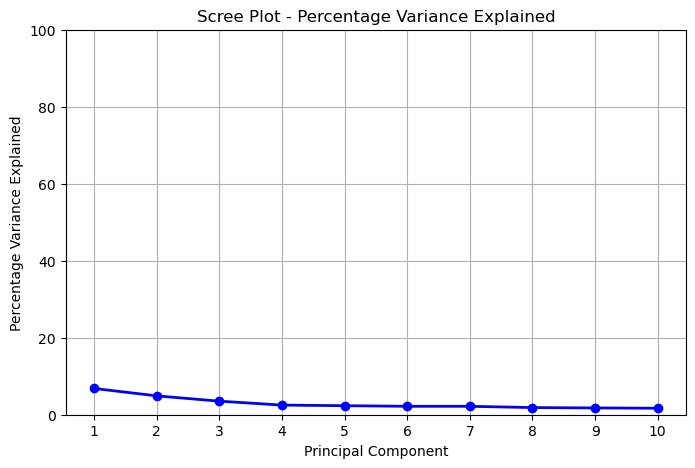

In [8]:
pca2.scree_plot()

### Using my PCA code: Scores plot

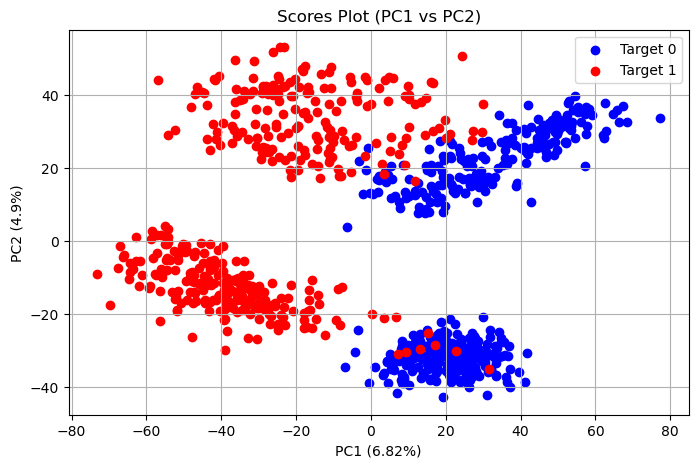

In [9]:
pca2.scores_plot(group_by_target=True, target_data=df_y)

### Sklearn PCA

In [10]:
# Applying PCA
pca = PCA()
pca_result = pca.fit_transform(transposed_data_scaled)

# Extracting PCA components, explained variance, and explained variance ratio
components = pca.components_
explained_variance = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_

# Displaying results
components[0:20], explained_variance[0:20], explained_variance_ratio[0:20]

(array([[-0.00654843, -0.00698362, -0.00636806, ..., -0.00014869,
         -0.00448358, -0.00738502],
        [-0.00717741,  0.01287274,  0.01518148, ...,  0.01233943,
         -0.0108511 , -0.01581409],
        [-0.00215395, -0.0242181 , -0.01856863, ..., -0.00248012,
         -0.0054498 ,  0.00019945],
        ...,
        [ 0.00482643, -0.0031872 ,  0.00751572, ...,  0.00602303,
          0.01190958,  0.00927212],
        [ 0.01724092, -0.00814579,  0.00257728, ..., -0.00154193,
          0.00047157,  0.00921824],
        [ 0.00544743, -0.0055431 , -0.02378863, ..., -0.00099243,
          0.00801784,  0.00164786]]),
 array([1066.06786339,  765.14477332,  549.77419754,  390.74299144,
         365.8793712 ,  342.02570847,  341.65618198,  289.92102159,
         274.96769549,  263.61187815,  233.47738021,  190.8811226 ,
         184.44615598,  167.13978473,  162.717066  ,  157.96569923,
         133.67444707,  124.08038122,  115.05657412,  101.0595343 ]),
 array([0.06823225, 0.04897207,

### Sklearn PCA: Scree plot

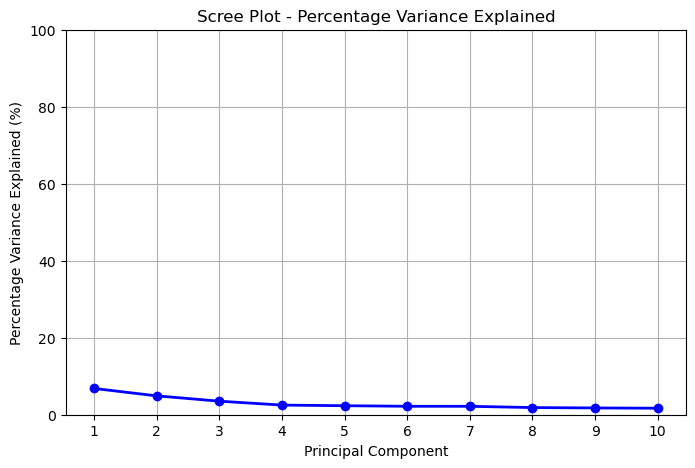

In [11]:
def plot_scree(save_path=None):
    num_components = len(explained_variance_ratio)
        
    # Plot only the first 10 principal components if there are more than 10
    if num_components > 10:
        components_to_plot = explained_variance_ratio[:10]
        x_ticks = range(1, 11)
    else:
        components_to_plot = explained_variance_ratio
        x_ticks = range(1, num_components + 1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(x_ticks, components_to_plot*100, 'o-', linewidth=2, color='blue')
    plt.title('Scree Plot - Percentage Variance Explained')
    plt.xlabel('Principal Component')
    plt.ylabel('Percentage Variance Explained (%)')
    plt.ylim(0, 100)
    plt.xticks(x_ticks)
    plt.grid(True)
    if save_path:
        plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
    plt.show()
    
plot_scree()

### Sklearn PCA: extract the top 6 principal components and plot PC1 and PC2

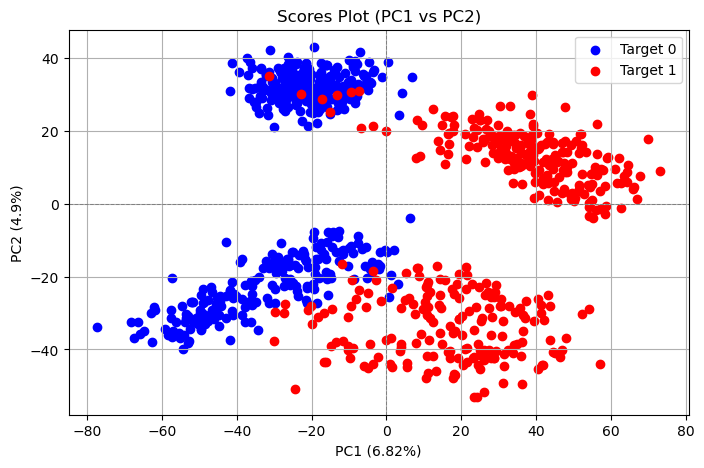

In [12]:
# Convert PCA scores to a DataFrame
pca_df = pd.DataFrame(data=pca_result[:,0:6], columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6'])
pca_df['Target'] = df_y['sample_label']

def plot_scores(save_path=None):
    plt.figure(figsize=(8, 5))
    #plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.7, edgecolors='k')
    
    colors = {0: 'blue', 1: 'red'}
    for target_value, group in pca_df.groupby('Target'):
        plt.scatter(group['PC1'], group['PC2'], color=colors[target_value],
                    label=f'Target {target_value}')

    plt.title('Scores Plot (PC1 vs PC2)')
    plt.xlabel('PC1 ({}%)'.format(round(explained_variance_ratio[0] * 100, 2)))
    plt.ylabel('PC2 ({}%)'.format(round(explained_variance_ratio[1] * 100, 2)))
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.7)
    plt.legend()
    plt.grid(True)
    if save_path:
        plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
    plt.show()

plot_scores()

### Save the dataframe of PC1-PC6 for logistic regression

In [13]:
pca_df['samples'] = transposed_data.index
pca_df.to_csv('PCA_new_dimensions.csv', index=False)
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,Target,samples
0,-1.195869,34.675642,-22.566091,-10.124487,5.437070,-27.289066,0,sample_1
1,56.219885,13.707433,-5.176982,-17.500171,1.755895,-25.040687,1,sample_2
2,-9.829854,28.700385,-9.131298,-8.827665,-17.923073,-37.253751,0,sample_3
3,63.601822,7.700061,-6.719630,-26.422956,-22.782805,-22.051176,1,sample_4
4,-9.944483,32.471231,-27.308476,-18.768296,-26.321906,-25.460404,0,sample_5
...,...,...,...,...,...,...,...,...
858,27.400601,-41.364723,26.597015,-14.626021,14.450297,-21.922266,1,sample_860
859,-50.426578,-33.143071,26.495926,-5.602025,14.432004,-28.201209,0,sample_861
860,11.732831,-31.312210,13.967708,-13.244061,22.363992,-18.355105,1,sample_862
861,-45.341685,-25.790150,19.330514,-2.792202,24.088169,-22.854234,0,sample_863


<br>
<br>

## Result summary:

### - The result when my code (that was built from scratch) was used for the analysis was similar to the result gotten using the Sklearn PCA package.
### - Elbow method was used to select principal components (PC1-PC6) for logsitic regression and ANN.